In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel(r"C:\Users\Paapi\Downloads\wine.csv.xlsx")

In [3]:
print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality type  
0      9.4        5  red  
1      9.8        5  red  
2    

In [4]:
print(df.shape)

(6497, 13)


Observation: 6497 rows and 13 columns in dataset

In [5]:
print(df.columns)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'type'],
      dtype='object')


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB
None


 Observation:12 numerical columns consists of float and int and 1 object which is the type for classification

In [7]:
print(df.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    6497.000000       6497.000000  6497.000000     6497.000000   
mean        7.215307          0.339666     0.318633        5.443235   
std         1.296434          0.164636     0.145318        4.757804   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.400000          0.230000     0.250000        1.800000   
50%         7.000000          0.290000     0.310000        3.000000   
75%         7.700000          0.400000     0.390000        8.100000   
max        15.900000          1.580000     1.660000       65.800000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  6497.000000          6497.000000           6497.000000  6497.000000   
mean      0.056034            30.525319            115.744574     0.994697   
std       0.035034            17.749400             56.521855     0.002999   
min       0.009000             1.000000         

Observation: Count is same4 as row no missing values.
Fixed acidity Maximum is much higher compared to mean so outliers possible,Volatile acidity also max is quite higher than mean so quality may get compromised,Residual sugar max is high compared to mean and median it is very high so might be there are outliers,Sulfer dioxide level should be moderate but in this max is so high,PH value is moderate and sulphate is also moderate,Higher alchol is also good,Quality of wine average is quite higher,

In [8]:
print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64


Observation: No missing values

In [9]:
print(df.duplicated().sum())

1177


In [10]:
df = df.drop_duplicates()

In [11]:
print(df.duplicated().sum())

0


In [12]:
print(df['type'].value_counts())

type
white    3961
red      1359
Name: count, dtype: int64


Observation: white wine is higher then red wine

In [13]:
df.groupby('type')[['alcohol','pH','density']].mean()

,alcohol,pH,density
type,,,
red,10.432315,3.309787,0.996709
white,10.589358,3.195458,0.993790


Observation: White wines have slightly higher average alcohol content than red wines.
Red wines have slightly higher pH values compared to white wines. as whiite wines are more acidic,Red wines have higher average density than white wines.


In [14]:
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
]
    print("Outliers count:", len(outliers))
    print(outliers)
    data_clean = df[
        (df[col] >= lower_bound) &
        (df[col] <= upper_bound)
]
    print("Clean data count:", len(data_clean))

Outliers count: 304
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
3              11.2             0.280         0.56             1.9      0.075   
56             10.2             0.420         0.57             3.4      0.070   
74              9.7             0.320         0.54             2.5      0.094   
113            10.1             0.310         0.44             2.3      0.080   
197            11.5             0.300         0.60             2.0      0.067   
...             ...               ...          ...             ...        ...   
5858            3.8             0.310         0.02            11.1      0.036   
6045            4.4             0.460         0.10             2.8      0.024   
6385            4.4             0.320         0.39             4.3      0.030   
6386            3.9             0.225         0.40             4.2      0.030   
6446            4.4             0.540         0.09             5.1      0.038   

      f

Observation: There are outliers.

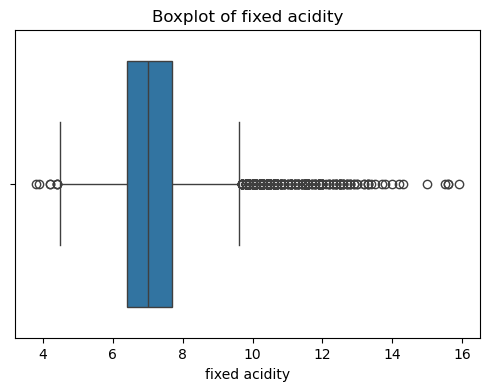

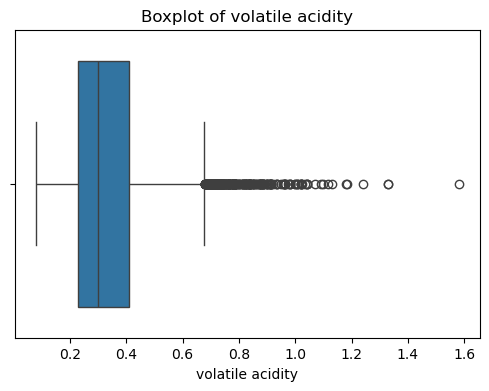

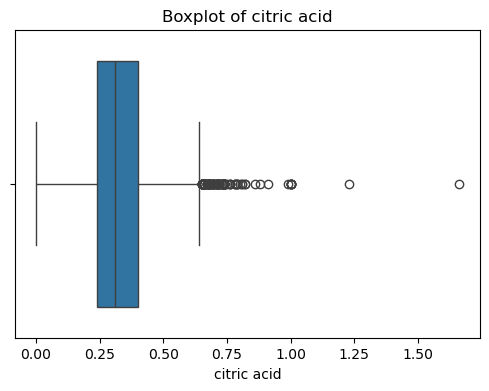

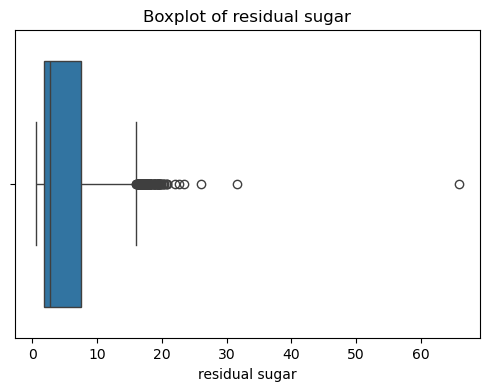

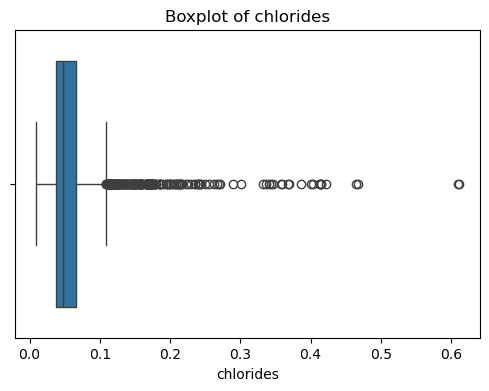

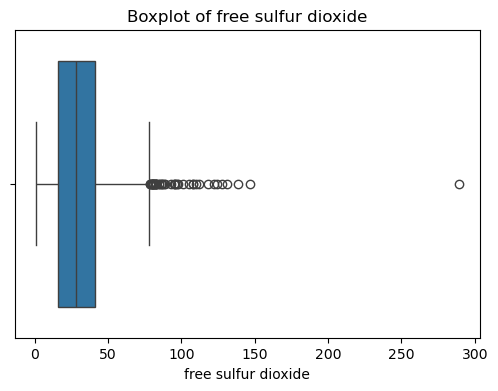

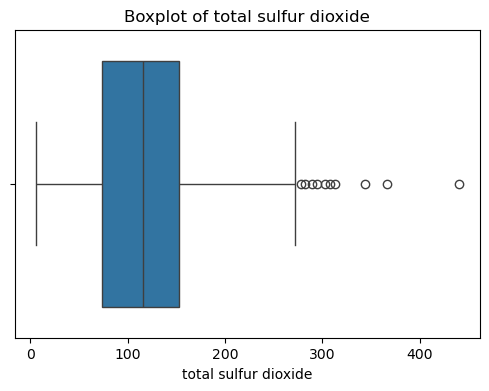

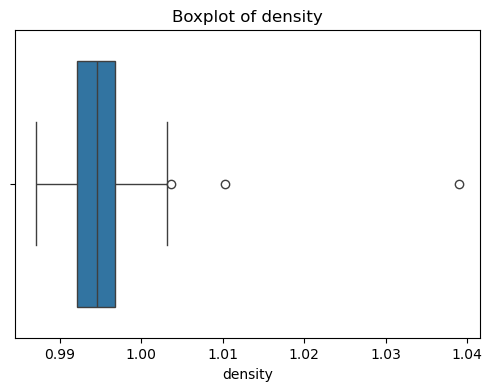

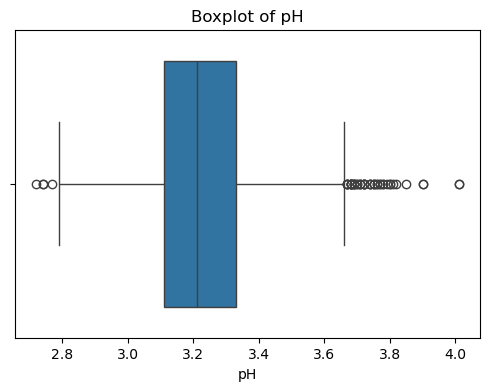

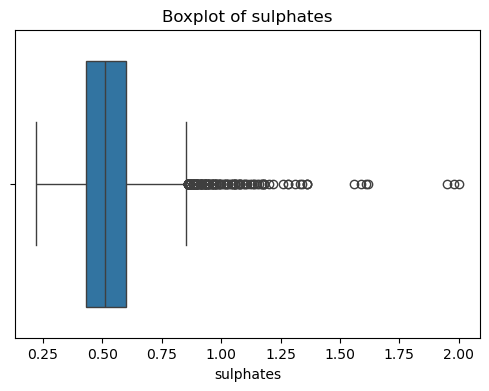

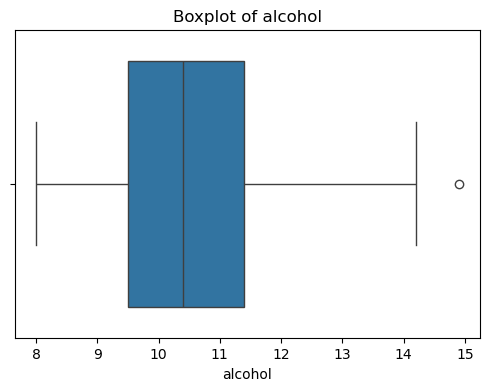

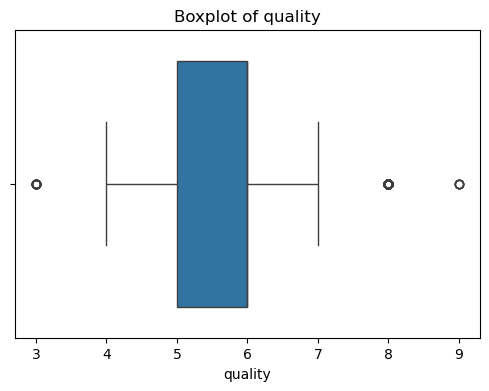

In [15]:
for col in df.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [16]:
from sklearn.preprocessing import LabelEncoder

In [17]:
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

In [18]:
print(le.classes_)

['red' 'white']


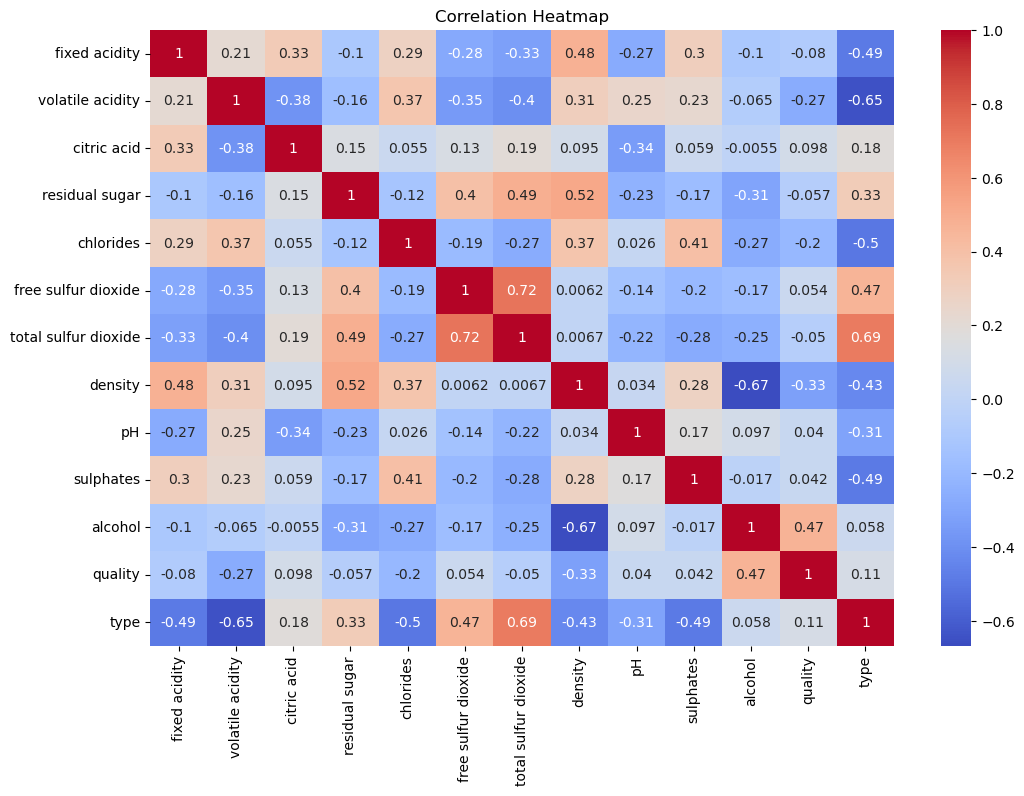

In [19]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

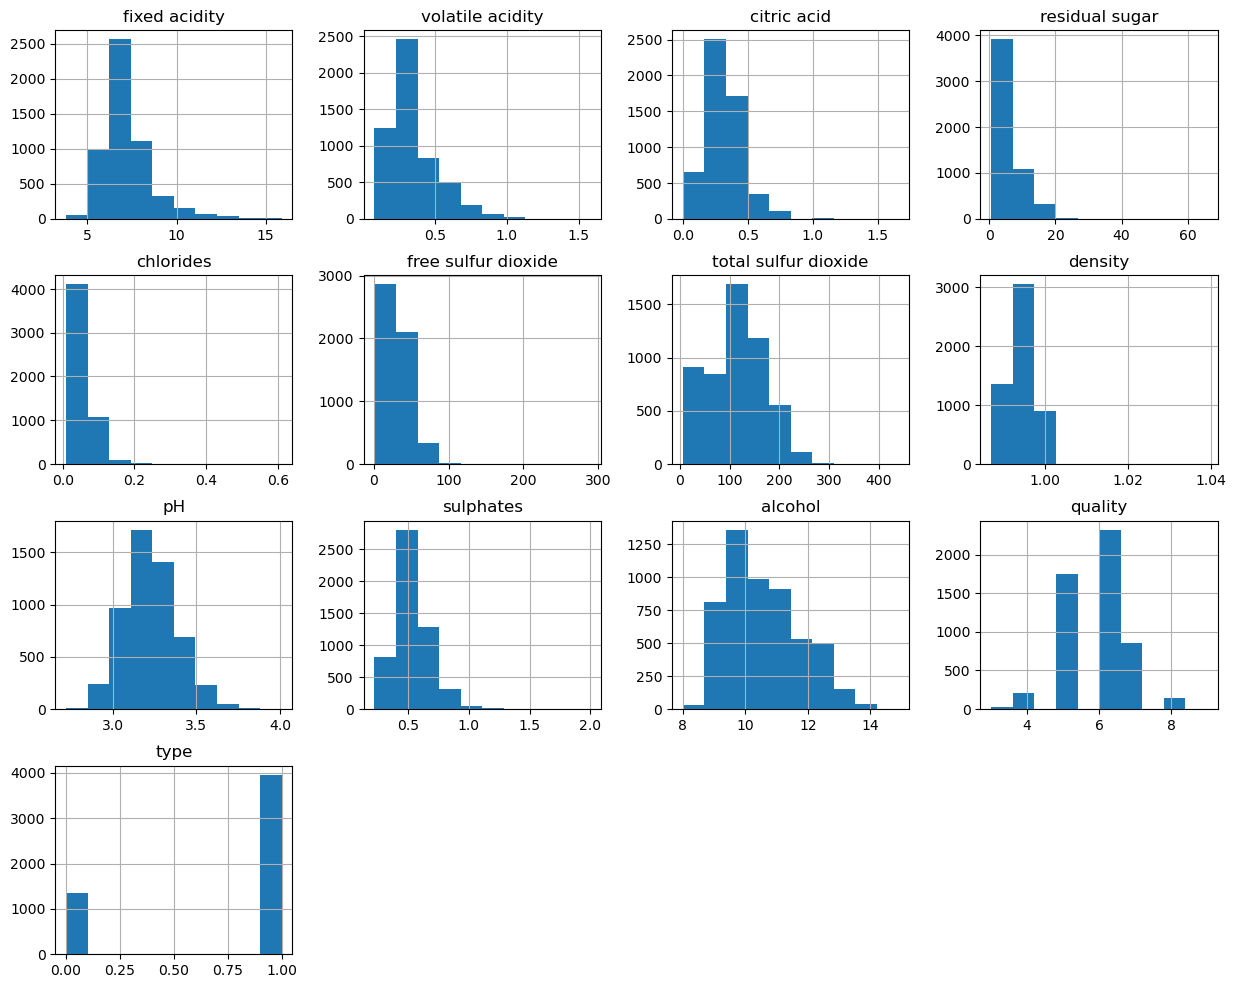

In [20]:
df.hist(figsize=(15,12))
plt.show()

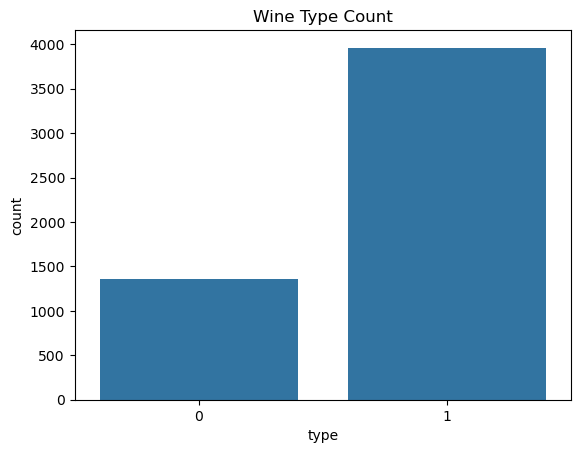

In [21]:
sns.countplot(x='type', data=df)
plt.title("Wine Type Count")
plt.show()

In [22]:
X = df.drop('type', axis=1)
y = df['type']

In [23]:
print(X.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
5            7.4              0.66         0.00             1.8      0.075   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
5                 13.0                  40.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [24]:
print(y.head())

0    0
1    0
2    0
3    0
5    0
Name: type, dtype: int64


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [31]:
knn = KNeighborsClassifier(
    n_neighbors=5,
    weights='uniform',
    metric='euclidean'
)

In [32]:
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [33]:
y_pred_knn = knn.predict(X_test)

In [34]:
print("KNN Accuracy:",
      accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.9924812030075187


Observation: KNN accuracy is good 

In [35]:
print(confusion_matrix(y_test, y_pred_knn))

[[288   1]
 [  7 768]]


Observation:  Red wine predicted true 288 and false 1, white wine predicted true 768 and false 7

In [36]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       289
           1       1.00      0.99      0.99       775

    accuracy                           0.99      1064
   macro avg       0.99      0.99      0.99      1064
weighted avg       0.99      0.99      0.99      1064



Observation: precision of white wine accurate 1 and red wine also is good, recall also red wine is accurate to 1, F1 score is 0.99 good balance between both.

In [57]:
from sklearn.metrics import roc_auc_score
y_prob_knn = knn.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_prob_knn)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9992454515012835


In [58]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [59]:
dt = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)

In [60]:
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [61]:
y_pred_dt = dt.predict(X_test)

In [62]:
print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9783834586466166


In [63]:
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

[[276  13]
 [ 10 765]]
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       289
           1       0.98      0.99      0.99       775

    accuracy                           0.98      1064
   macro avg       0.97      0.97      0.97      1064
weighted avg       0.98      0.98      0.98      1064



Observation: Accuracy is low compared to KNN, even precision recall and f1 score is low .

In [65]:
from sklearn.metrics import roc_auc_score
y_prob_dt = dt.predict_proba(X_test)[:,1]
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)
print("Decision Tree ROC-AUC Score:", roc_auc_dt)

Decision Tree ROC-AUC Score: 0.9758946310972206


In [66]:
lr = LogisticRegression()

In [67]:
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9953007518796992


In [68]:
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

[[287   2]
 [  3 772]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       289
           1       1.00      1.00      1.00       775

    accuracy                           1.00      1064
   macro avg       0.99      0.99      0.99      1064
weighted avg       1.00      1.00      1.00      1064



obervation: Classification is accurate in terms of accuracyy precion recall f1 score better then knn and decion tree

In [69]:
from sklearn.metrics import roc_auc_score
y_prob_lr = lr.predict_proba(X_test)[:,1]
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
print("Logistic Regression ROC-AUC Score:", roc_auc_lr)

Logistic Regression ROC-AUC Score: 0.9999062395356624


In [56]:
print("KNN Accuracy:",
      accuracy_score(y_test, y_pred_knn))
print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

KNN Accuracy: 0.9924812030075187
Decision Tree Accuracy: 0.9783834586466166
Logistic Regression Accuracy: 0.9953007518796992
